In [2]:
import numpy as np
import matplotlib.pyplot as plt

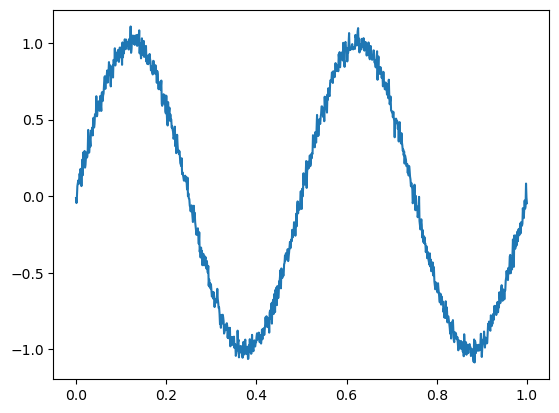

In [3]:
N = 1000
noise_amp = 0.04

t = np.linspace(0, 1, N)
y = np.sin(2 * np.pi * 2 * t)
noise = np.random.randn(N) * noise_amp
y += noise

plt.plot(t, y)

C:\Users\zeyad\AppData\Local\Temp\ipykernel_5076\2601431395.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fixed_points[i] = x[0]


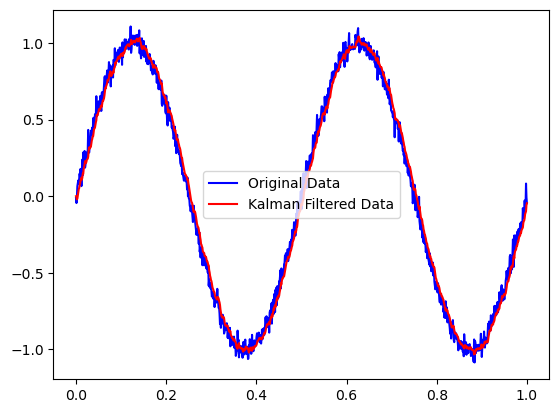

In [4]:
# Knobs
def kalman_filter(data: np.ndarray, Q_scale, R):
    # Q: Process Noise
    # R: Sensor Noise
    Q = np.eye(2) * Q_scale
    R = R

    # State Transition matrix
    dt = 1 / len(data)
    F = np.array(
        [
            [1, dt],
            [0, 1],
        ]
    )

    # Observation matrix (observes pos not velocities)
    H = np.array([[1, 0]])

    x = np.zeros((2, 1))
    I = np.eye(2)
    P = np.eye(2) * 500

    fixed_points = np.zeros(N)

    for i, point in enumerate(data):
        # 1. Predict
        x = F @ x
        P = F @ P @ F.T + Q
        fixed_points[i] = x[0]

        # 2. Update
        K = P @ H.T / (H @ P @ H.T + R)  # ends up as Sensor Uncertainty / (Sensor Uncertainty + Noise Uncertainty), less K means we trust sensors more
        x = x + K @ (
            point - H @ x
        )  # (z - H x) is innovation, how surprised we are from the real data measurment, scale by K so that less K indicating we dont' trust real world sensors woudl scale the surprise down as it's untrusted
        P = (
            I - K @ H
        ) @ P  # if sensor noise is high, K gets low, so I - K@H gets high, meaning we don't lower P the uncertainty much, if sensor values are trusted them K gets high, I - K@H gets low so we lower uncertainty
        
    return fixed_points
    
fixed_points = kalman_filter(y, Q_scale=34, R=500)


plt.plot(t, y, "b", label="Original Data")
plt.plot(t, fixed_points, "r", label="Kalman Filtered Data")
plt.legend()
# plt.xlim(0.2, 0.3)

In [121]:
np.sum((data[:, 1] - fixed_points)**2)

np.float64(324.67333988951555)